In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt

# 16b - Jaynes-Cummings Hamiltonian (in QuanGuru)

The Jaynes-Cummings Hamiltonian is written as

$H_{JC} = \hbar\omega_{c} a^{\dagger}a + \frac{1}{2}\hbar\omega_{q}\sigma_{z} + \hbar g(a^{\dagger}\sigma_{-} + a\sigma_{+})$

where $\sigma_{\pm} = (\sigma_{x} \pm i\sigma_{y})/2$ are raising/lowering operators for a two-level system, $\sigma_{\mu}$ are the Pauli spin operators with $\mu\in\{x,y,z\}$, $a^{\dagger}$ and $a$ are the creation and annihilation operators for the field mode, and $\omega_{c}$, $\omega_{q}$, and $g$ are the cavity-field, qubit, and coupling (angular-) frequencies, respectively.
Note that the above Hamiltonian is written in a common notation where the order of the sub-system Hilbert spaces is implicitly defined by the ordering in the coupling.
This means, for example, that the composite form of the number operator is written explicitly as $(a^{\dagger}a)\otimes 1_{2,2}$ (similarly, $a^{\dagger}\otimes\sigma_{-}$ and $1_{d,d}\otimes\sigma_{z}$, where $d$ is the truncation dimension for the cavity operators and $\otimes$ is the tensor product).

In this tutorial, we describe/create the Jaynes-Cummings Hamiltonian using `QuanGuru`.
For the parameters of the Hamiltonian, we will take $\omega_{c} = \omega_{q} = g = 1/2\pi$ for simplicity. Since, `QuanGuru` uses frequencies (instead of angular-frequencies), frequencies are all 1.
Also, instead of $\sigma_{\pm} = (\sigma_{x} \pm i\sigma_{y})/2$, we will use $J_{\pm} = (J_{x} \pm iJ_{y})/2$, where $J_{\mu}$ (with $\mu\in\{x,y,z\}$) are the operators for large spins.
With this approach, we will be able to extend the Jaynes-Cummings Hamiltonian to Tavis-Cumming Hamiltonian by simply setting a different j-value to our `Qubit` object.

In [2]:
# create a composite system with a qubit and cavity
qubitJC = qg.Qubit(frequency=1, alias="JC_Qubit")
cavityJC = qg.Cavity(frequency=1, dimension=5, alias="JC_Cavity")

JCSystem = qubitJC + cavityJC

# couple the qubit and the cavity using their alias
couplingTerm_minusCreate = JCSystem.createTerm(qSystem=["JC_Qubit", "JC_Cavity"], operator=[qg.sigmam, qg.create], frequency=1)
couplingTerm_plusDestroy = JCSystem.createTerm(qSystem=["JC_Qubit", "JC_Cavity"], operator=[qg.sigmap, qg.destroy], frequency=1)

In the context of the Jaynes-Cummings Hamiltonian, the total Hamiltonian can be decomposed into diagonal and off-diagonal components, which represent different physical aspects of the system.

In QuanGuru, the total Hamiltonian of the system can be effectively analyzed by isolating its diagonal and off-diagonal components. This is achieved through the distinction between the `subSys` and `terms` Hamiltonians.


[[ 0.5   0.    0.    0.    0.    0.    1.    0.    0.    0.  ]
 [ 0.    1.5   0.    0.    0.    0.    0.    1.41  0.    0.  ]
 [ 0.    0.    2.5   0.    0.    0.    0.    0.    1.73  0.  ]
 [ 0.    0.    0.    3.5   0.    0.    0.    0.    0.    2.  ]
 [ 0.    0.    0.    0.    4.5   0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -0.5   0.    0.    0.    0.  ]
 [ 1.    0.    0.    0.    0.    0.    0.5   0.    0.    0.  ]
 [ 0.    1.41  0.    0.    0.    0.    0.    1.5   0.    0.  ]
 [ 0.    0.    1.73  0.    0.    0.    0.    0.    2.5   0.  ]
 [ 0.    0.    0.    2.    0.    0.    0.    0.    0.    3.5 ]]


([], [])

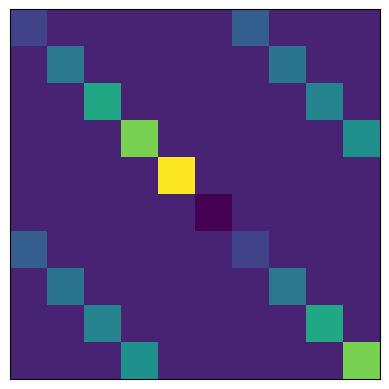

In [3]:
# Hamiltonian of the total system
print(np.round(JCSystem.totalHamiltonian.toarray(), 2))
plt.imshow(JCSystem.totalHamiltonian.toarray())
plt.xticks([]); plt.yticks([])


The diagonal elements of the Hamiltonian, which correspond to the individual energies of the qubit and cavity, can be accessed through  `_subSysHamiltonian`. This attribute contains the Hamiltonian of the subsystem without any interaction terms. 


[[ 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   1.5  0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   2.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   3.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   4.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   1.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   2.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   0.   3.5]]


([], [])

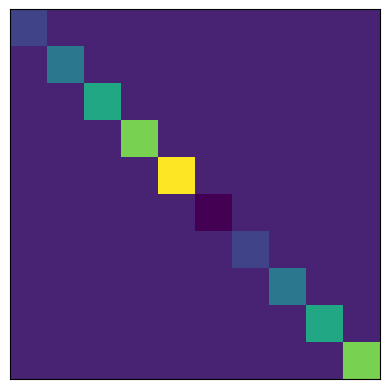

In [4]:
# Hamiltonian containing only diagonal elements of the subsystem (qubit + cavity) without interaction terms
print(np.round(JCSystem._subSysHamiltonian.toarray(), 2))
plt.imshow(JCSystem._subSysHamiltonian.toarray())
plt.xticks([]); plt.yticks([])


The off-diagonal elements, which represent the interaction between the qubit and the cavity, can be accessed through `_termHamiltonian`. These describe how the qubit and cavity interact and exchange energy.

[[0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.41 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   1.73 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   2.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   1.41 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.73 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   2.   0.   0.   0.   0.   0.   0.  ]]


([], [])

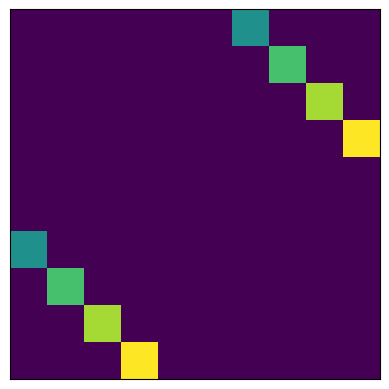

In [5]:
# Hamiltonian containging only off-diagonal elements of the interaction terms only
print(np.round(JCSystem._termHamiltonian.toarray(), 2))
plt.imshow(JCSystem._termHamiltonian.toarray())
plt.xticks([]); plt.yticks([])
